Goal:
Train the same linear classifier f(x)=w⊤x+bf(x)=w^\top x + bf(x)=w⊤x+b using three losses:

MSE (squared error)

Cross‑entropy (logistic loss)

Hinge loss (SVM‑style)

Compare convergence, decision boundaries, and metrics.

We’ll use a 2D binary dataset so you can visualize boundaries.

In [1]:
# pip install numpy matplotlib scikit-learn
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
np.random.seed(0)

Data (2D, moderately separable)

In [2]:
X, y01 = make_classification(
    n_samples=1200, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.2, flip_y=0.03, random_state=0
)
# labels in {-1, +1} for margin-based losses
y = np.where(y01==1, 1, -1)
 
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

2) Model / utilities

We’ll learn w (2,) and bias b with full‑batch gradient descent and optional L2.

In [3]:
def decision_function(X, w, b):  # scores s = w^T x + b
    return X @ w + b
 
def preds_from_scores(s):        # class labels {-1,+1}
    return np.where(s>=0, 1, -1)
 
def proba_from_scores(s):        # for AUC (use sigmoid)
    return 1/(1+np.exp(-s))
 
def plot_boundary(ax, X, y, w, b, title):
    ax.scatter(X[y==1,0], X[y==1,1], s=12, label='+1')
    ax.scatter(X[y==-1,0],X[y==-1,1], s=12, label='-1')
    # line: w0 x + w1 y + b = 0 -> y = -(w0 x + b)/w1
    xline = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
    if abs(w[1])<1e-9:
        ax.axvline(-b/w[0], ls='--', c='k')
    else:
        ax.plot(xline, -(w[0]*xline + b)/w[1], 'k--')
    ax.set_title(title); ax.legend(loc='upper right')

3) Losses & gradients (shared linear score s=y⋅(w⊤x+b)s = y\cdot(w^\top x + b)s=y⋅(w⊤x+b))
We’ll write each loss in terms of the margin mi=yi⋅sim_i = y_i \cdot s_imi​=yi​⋅si​.

MSE (on score): L=12N∑i(yi−si)2+λ2∥w∥2L = \tfrac{1}{2N}\sum_i (y_i - s_i)^2 + \tfrac{\lambda}{2}\|w\|^2L=2N1​∑i​(yi​−si​)2+2λ​∥w∥2
∇w=−1N∑i(yi−si)xi+λw\nabla_w = -\tfrac{1}{N}\sum_i (y_i - s_i)x_i + \lambda w∇w​=−N1​∑i​(yi​−si​)xi​+λw,
∇b=−1N∑i(yi−si)\nabla_b = -\tfrac{1}{N}\sum_i (y_i - s_i)∇b​=−N1​∑i​(yi​−si​)

Logistic / Cross‑Entropy: L=1N∑ilog⁡(1+exp⁡(−mi))+λ2∥w∥2L = \tfrac{1}{N}\sum_i \log(1+\exp(-m_i)) + \tfrac{\lambda}{2}\|w\|^2L=N1​∑i​log(1+exp(−mi​))+2λ​∥w∥2
∇w=−1N∑iσ(−mi)yixi+λw\nabla_w = -\tfrac{1}{N}\sum_i \sigma(-m_i) y_i x_i + \lambda w∇w​=−N1​∑i​σ(−mi​)yi​xi​+λw,
∇b=−1N∑iσ(−mi)yi\nabla_b = -\tfrac{1}{N}\sum_i \sigma(-m_i) y_i∇b​=−N1​∑i​σ(−mi​)yi​, where σ(z)=1/(1+e−z)\sigma(z)=1/(1+e^{-z})σ(z)=1/(1+e−z)

Hinge: L=1N∑imax⁡(0,1−mi)+λ2∥w∥2L = \tfrac{1}{N}\sum_i \max(0, 1 - m_i) + \tfrac{\lambda}{2}\|w\|^2L=N1​∑i​max(0,1−mi​)+2λ​∥w∥2
Subgradient on active set {i:mi<1}\{i: m_i<1\}{i:mi​<1}:
∇w=−1N∑mi<1yixi+λw\nabla_w = -\tfrac{1}{N}\sum_{m_i<1} y_i x_i + \lambda w∇w​=−N1​∑mi​<1​yi​xi​+λw,
∇b=−1N∑mi<1yi\nabla_b = -\tfrac{1}{N}\sum_{m_i<1} y_i∇b​=−N1​∑mi​<1​yi​


In [4]:
def grad_mse(X, y, w, b, l2):
    s = decision_function(X, w, b)          # (N,)
    r = (y - s)                              # residual
    dw = -(X.T @ r) / X.shape[0] + l2*w
    db = -np.mean(r)
    # loss for logging
    L  = 0.5*np.mean((y - s)**2) + 0.5*l2*np.sum(w*w)
    return L, dw, db
 
def grad_logistic(X, y, w, b, l2):
    s = decision_function(X, w, b)
    m = y * s
    sig = 1/(1+np.exp(m))  # = sigmoid(-m)
    # gradients
    dw = -(X.T @ (sig * y)) / X.shape[0] + l2*w
    db = -np.mean(sig * y)
    L  = np.mean(np.log(1 + np.exp(-m))) + 0.5*l2*np.sum(w*w)
    return L, dw, db
 
def grad_hinge(X, y, w, b, l2):
    s = decision_function(X, w, b)
    m = y * s
    active = m < 1
    if np.any(active):
        dw = -(X[active].T @ y[active]) / X.shape[0] + l2*w
        db = -np.mean(y[active])
    else:
        dw = l2*w
        db = 0.0
    L = np.mean(np.maximum(0, 1 - m)) + 0.5*l2*np.sum(w*w)
    return L, dw, db

Training loop (full‑batch GD)

In [5]:
def train_gd(X, y, loss_grad_fn, lr=0.1, epochs=400, l2=1e-3, w0=None, b0=0.0):
    w = np.zeros(X.shape[1]) if w0 is None else w0.copy()
    b = float(b0)
    hist = []
    for ep in range(1, epochs+1):
        L, dw, db = loss_grad_fn(X, y, w, b, l2)
        w -= lr * dw
        b -= lr * db
        if ep==1 or ep%10==0:
            hist.append(L)
    return w, b, np.array(hist)

Train with each loss & compare

In [6]:
cfgs = {
    "MSE":      dict(fn=grad_mse,      lr=0.05, epochs=600, l2=1e-3),
    "CrossEnt": dict(fn=grad_logistic, lr=0.10, epochs=600, l2=1e-3),
    "Hinge":    dict(fn=grad_hinge,    lr=0.05, epochs=600, l2=1e-3),
}
 
fits = {}
for name, c in cfgs.items():
    w, b, hist = train_gd(Xtr, ytr, c["fn"], lr=c["lr"], epochs=c["epochs"], l2=c["l2"])
    fits[name] = (w, b, hist)
 
# Metrics
for name, (w,b,_) in fits.items():
    s_te = decision_function(Xte, w, b)
    yhat = preds_from_scores(s_te)
    acc  = accuracy_score(yte, yhat)
    auc  = roc_auc_score((yte==1).astype(int), proba_from_scores(s_te))
    print(f"{name:9s} | Acc={acc:.3f}  AUC={auc:.3f}")

MSE       | Acc=0.930  AUC=0.945
CrossEnt  | Acc=0.920  AUC=0.944
Hinge     | Acc=0.927  AUC=0.945


Plot loss curves:

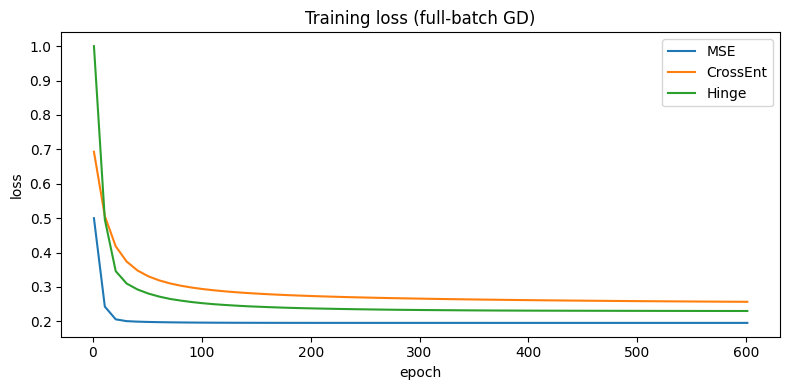

In [7]:
plt.figure(figsize=(8,4))
for name, (_,_,hist) in fits.items():
    steps = np.arange(len(hist))*10 + 1
    plt.plot(steps, hist, label=name)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training loss (full-batch GD)")
plt.legend(); plt.tight_layout(); plt.show()

Decision boundaries:

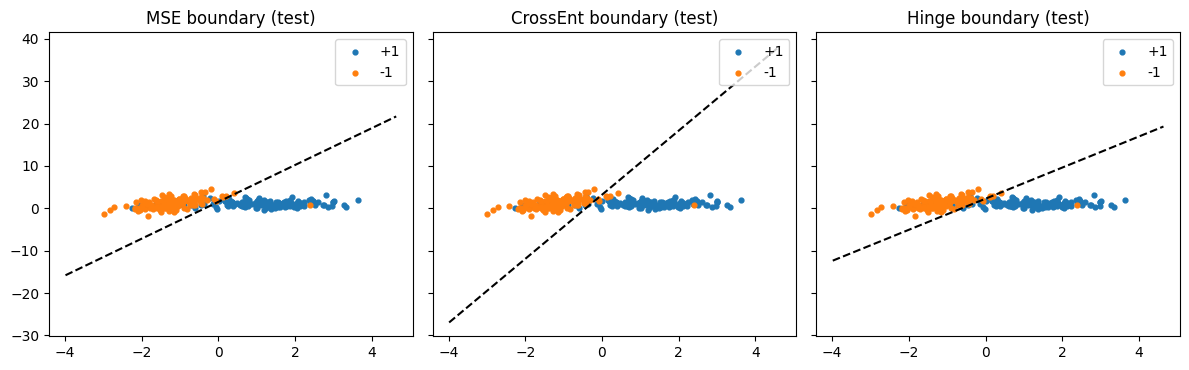

In [8]:
fig, axes = plt.subplots(1,3, figsize=(12,3.8), sharex=True, sharey=True)
for ax, (name, (w,b,_)) in zip(axes, fits.items()):
    plot_boundary(ax, Xte, yte, w, b, f"{name} boundary (test)")
plt.tight_layout(); plt.show()

What to look for
Cross‑entropy typically yields the best calibrated boundary and strong AUC/accuracy.

Hinge focuses on margin; often similar accuracy, sometimes crisper boundaries (but subgradient can be noisier).

MSE treats it like regression; can work, but typically slower and less robust to outliers/imbalance for classification.

Regularization sweep: For each loss, try l2 ∈ {0, 1e-4, 1e-3, 1e-2}. Plot test AUC vs l2. Which loss benefits most?

Loss Function   | L2 Value   | Test AUC  
----------------------------------------
log_loss        | 0          | 0.8110
log_loss        | 0.0001     | 0.8115
log_loss        | 0.001      | 0.9032
log_loss        | 0.01       | 0.9057
hinge           | 0          | 0.8905
hinge           | 0.0001     | 0.8752
hinge           | 0.001      | 0.8974
hinge           | 0.01       | 0.9008
squared_error   | 0          | 0.6547
squared_error   | 0.0001     | 0.6546
squared_error   | 0.001      | 0.8682
squared_error   | 0.01       | 0.8991


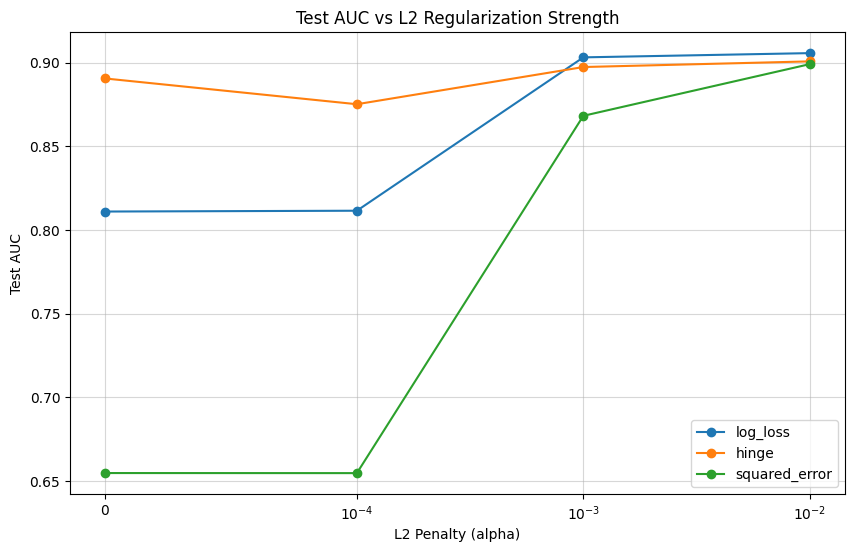

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def run_regularization_sweep():
    # 1. Generate synthetic data
    X, y = make_classification(
        n_samples=1000, 
        n_features=20, 
        n_informative=10, 
        n_classes=2, 
        random_state=42
    )

    # 2. Split and Scale Data
    # Scaling is crucial when using Regularization (L2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # 3. Define Sweep Parameters
    # In SGDClassifier, 'alpha' is the regularization strength multiplier
    l2_values = [0, 1e-4, 1e-3, 1e-2]
    
    # Define losses to compare: 
    # 'log_loss' = Logistic Regression
    # 'hinge' = Linear SVM
    # 'squared_error' = Linear Regression (treated as classification here)
    losses = ['log_loss', 'hinge', 'squared_error']
    
    results = {loss: [] for loss in losses}

    # 4. Run Sweep
    print(f"{'Loss Function':<15} | {'L2 Value':<10} | {'Test AUC':<10}")
    print("-" * 40)

    for loss_name in losses:
        for l2 in l2_values:
            # Handle l2=0 case (no penalty)
            penalty = 'l2' if l2 > 0 else None
            
            clf = SGDClassifier(
                loss=loss_name,
                penalty=penalty,
                alpha=l2 if l2 > 0 else 0.0001, # alpha is ignored if penalty is None
                max_iter=1000,
                tol=1e-3,
                random_state=42
            )
            
            clf.fit(X_train, y_train)
            
            # Use decision_function for AUC (works for both Log and Hinge)
            y_scores = clf.decision_function(X_test)
            auc = roc_auc_score(y_test, y_scores)
            
            results[loss_name].append(auc)
            print(f"{loss_name:<15} | {l2:<10} | {auc:.4f}")

    # 5. Plotting
    plt.figure(figsize=(10, 6))
    
    for loss_name, auc_scores in results.items():
        plt.plot(l2_values, auc_scores, marker='o', label=loss_name)

    plt.title('Test AUC vs L2 Regularization Strength')
    plt.xlabel('L2 Penalty (alpha)')
    plt.ylabel('Test AUC')
    plt.xscale('symlog', linthresh=1e-4) # Symlog allows plotting 0 on a log-like scale
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_regularization_sweep()


In [1]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. Prepare the Data
# Let's assume X is square footage (normalized: 1.0 = 1000 sqft)
# Let's assume y is price (normalized: 2.0 = $200k)
# We want the model to learn the relationship: Price = 2 * Size
X_train = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)
y_train = torch.tensor([[2.0], [4.0], [6.0], [8.0]], dtype=torch.float32)

# 2. Define the Model (Linear Regression)
# Linear layer: y = wx + b
model = nn.Linear(in_features=1, out_features=1)

# 3. Define the Loss Function and Optimizer
# MSELoss calculates the mean squared error between prediction and actual value
criterion = nn.MSELoss() 

# SGD (Stochastic Gradient Descent) will adjust weights to reduce the loss
optimizer = optim.SGD(model.parameters(), lr=0.01)

print(f"Initial Loss (Random Guessing):")
with torch.no_grad():
    y_pred_initial = model(X_train)
    initial_loss = criterion(y_pred_initial, y_train)
    print(f"Loss: {initial_loss.item():.4f}\n")

# 4. Training Loop
epochs = 1000
for epoch in range(epochs):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(X_train)

    # Compute and print loss
    loss = criterion(y_pred, y_train)

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 5. Test the Model
# Predict price for a house of 5000 sqft (input 5.0)
new_house_size = torch.tensor([[5.0]])
predicted_price = model(new_house_size).item()

print(f"\nFinal Prediction for 5.0 input: {predicted_price:.4f}")
print(f"Expected value was roughly 10.0")


Initial Loss (Random Guessing):
Loss: 60.6629

Epoch [200/1000], Loss: 0.0392
Epoch [400/1000], Loss: 0.0118
Epoch [600/1000], Loss: 0.0036
Epoch [800/1000], Loss: 0.0011
Epoch [1000/1000], Loss: 0.0003

Final Prediction for 5.0 input: 9.9693
Expected value was roughly 10.0
